$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ 8 de Maio de 2026

$ \textbf{Estudo Orientado - 2026.1:}$ Análise de quantis extremos de precipitação usando o modelo do Naveau

In [1]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from arch import arch_model
import numdifftools as nd
from statsmodels.tools.numdiff import approx_hess
from scipy.optimize import minimize
from naveau_model import NaveauModelI as naveau

In [2]:
rng = np.random.default_rng(seed=4)
path_img = r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\EO - naveau"

# Dados

In [3]:
data = pd.read_excel(r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\Serie Temporal INMET 2008-2024.xlsx").rename(columns={'Data': 'data', 'PRECIPITACAO TOTAL, DIARIA(mm)': 'precipitacao'})
data['data'] = pd.to_datetime(data['data'])
series = data[['precipitacao','data']].set_index('data')['precipitacao']

data.head()

,data,precipitacao,"VENTO, RAJADA MAXIMA(m/s)"
0,2008-01-01,0.0,8.6
1,2008-01-02,0.0,6.9
2,2008-01-03,0.0,10.3
3,2008-01-04,0.0,9.5
4,2008-01-05,14.2,20.1


In [4]:
series = series[series.index < pd.to_datetime('2025-04-26')]
pd.DataFrame(index=['Metadados'], data={
    'Série':'Precipitação diária no Rio (mm)', 
    'Fonte': 'Inmet',
    'Período da série': '{} a {}'.format(series.index[0].strftime('%d/%m/%Y'), series.index[-1].strftime('%d/%m/%Y')),
    'Observações': '{}'.format(series.shape[0]),
    'Observações iguais a zero': '{} ({:.0%})'.format((series==0).sum(), (series==0).sum()/series.shape[0]),
}).T

,Metadados
Série,Precipitação diária no Rio (mm)
Fonte,Inmet
Período da série,01/01/2008 a 31/12/2024
Observações,6122
Observações iguais a zero,3769 (62%)


In [5]:
meses_molhado = [11,12,1,2,3,4]
meses_seco = [5,6,7,8,9,10]

series_molhado = series[series.index.month.isin(meses_molhado)]
series_seco = series[series.index.month.isin(meses_seco)]

n, n1 = len(series_molhado), len(series_molhado[series_molhado>0])
print("Estação molhada (Nov a Abr): \n{} observações, {} positivas ({:.0%})".format(n, n1, n1/n))
n, n1 = len(series_seco), len(series_seco[series_seco>0])
print("\nEstação seca (Mai a Out): \n{} observações, {} positivas ({:.0%})".format(n, n1, n1/n))

Estação molhada (Nov a Abr): 
3068 observações, 1329 positivas (43%)

Estação seca (Mai a Out): 
3054 observações, 1024 positivas (34%)


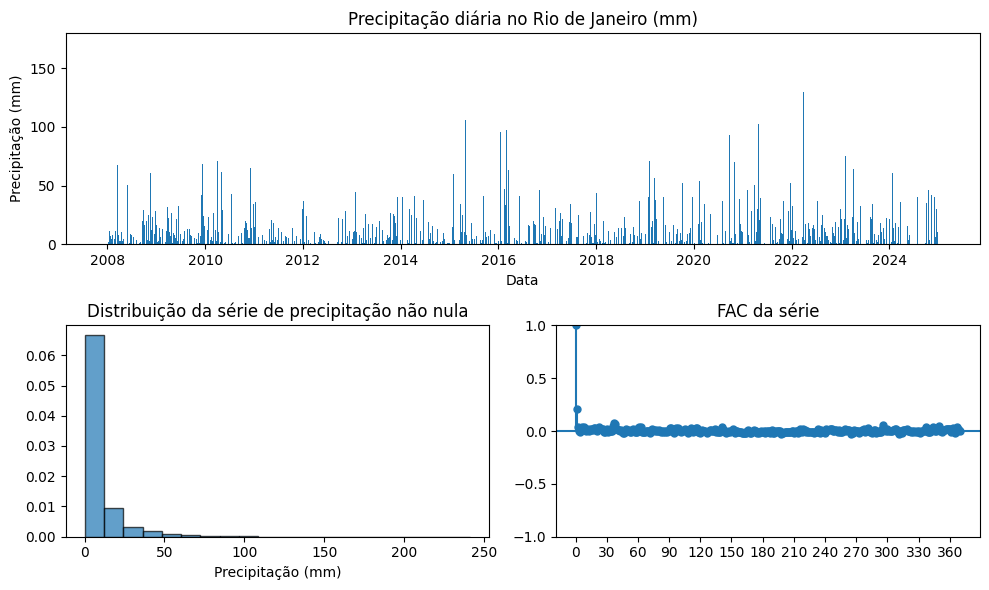

In [6]:
plot_count = 0

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(series.index, series, width=4)
ax0.set_title('Precipitação diária no Rio de Janeiro (mm)')
ax0.set_ylabel('Precipitação (mm)')
ax0.set_xlabel('Data')
ax0.set_ylim(top=180)

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(series[series>0], bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Distribuição da série de precipitação não nula')
ax1.set_xlabel('Precipitação (mm)')

ax2 = fig.add_subplot(gs[1, 1])
lags = 370
plot_acf(series, lags=lags, ax=ax2, title='FAC da série')
ax2.set_xticks(np.arange(0, lags+1, 30))
ax2.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

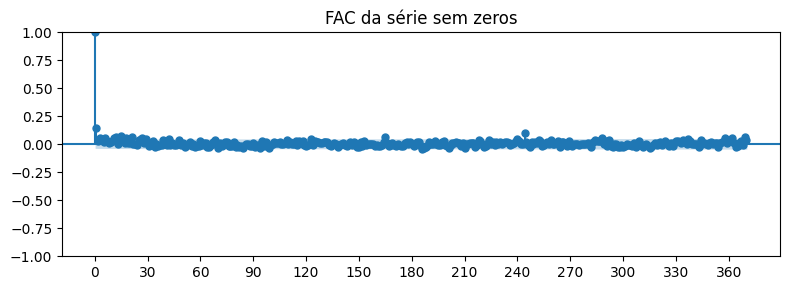

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))

lags = 370
plot_acf(series[series>0], lags=lags, ax=ax, title='FAC da série sem zeros')
ax.set_xticks(np.arange(0, lags+1, 30))
ax.set_xticklabels(np.arange(0, lags+1, 30))

fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [8]:
print('Autocorrelação nos últimos lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[364:]

Autocorrelação nos últimos lags:


array([ 0.0047605 , -0.01630743, -0.00622613,  0.03551257,  0.02114607,
        0.01367062, -0.0022198 ])

In [9]:
print('Autocorrelação nos primeiros lags:')
acf_vals = acf(series, nlags=370, fft=True)
acf_vals[:5]

Autocorrelação nos primeiros lags:


array([ 1.        ,  0.21192431,  0.03521613,  0.00221591, -0.01005837])

In [10]:
print('Autocorrelação nos primeiros lags (sem zero):')
acf_vals = acf(series[series>0], nlags=370, fft=True)
acf_vals[:5]

Autocorrelação nos primeiros lags (sem zero):


array([1.        , 0.14714625, 0.02582618, 0.05382026, 0.0429673 ])

## Dados mensais

In [11]:
series_mensal = series.resample('ME').sum()

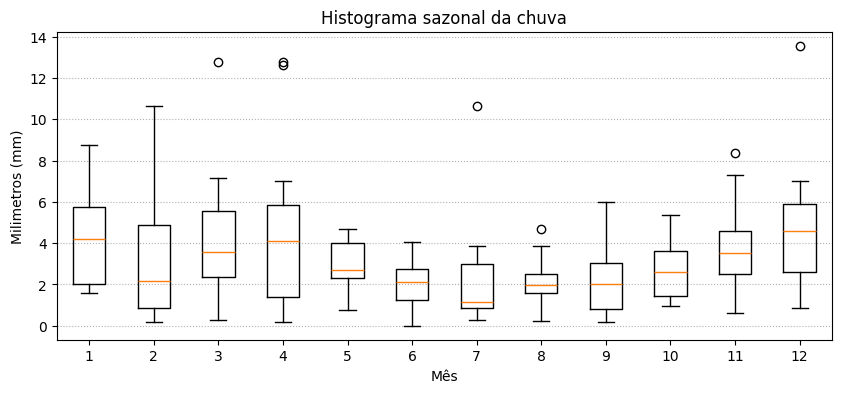

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = (series.to_frame()
    .pivot_table(columns=series.index.month, index=series.index.year, values='precipitacao')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_ylabel('Milimetros (mm)')
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma sazonal da chuva')
plt.show()

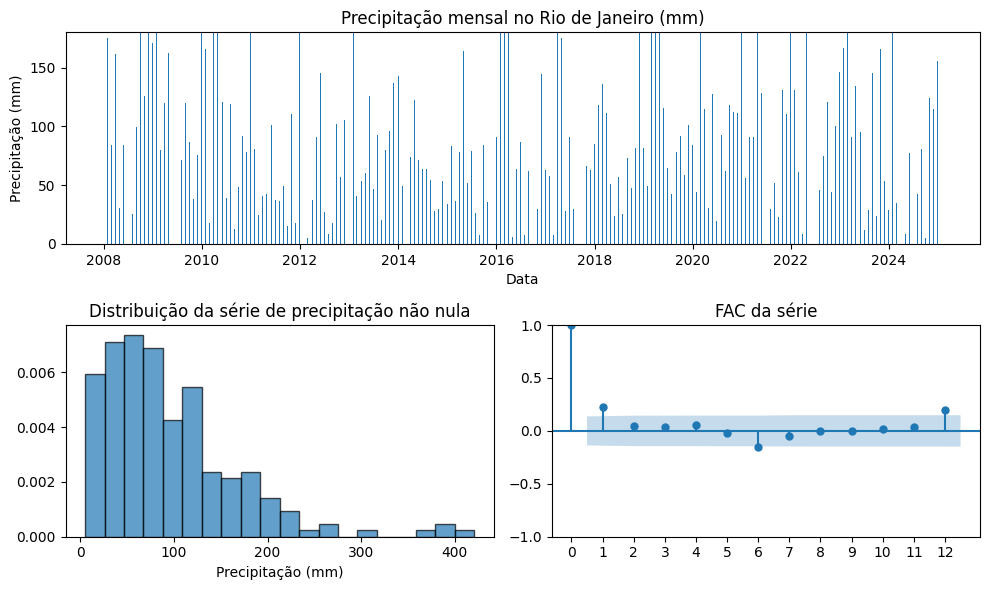

In [13]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, :])
ax0.bar(series_mensal.index, series_mensal, width=7)
ax0.set_title('Precipitação mensal no Rio de Janeiro (mm)')
ax0.set_ylabel('Precipitação (mm)')
ax0.set_xlabel('Data')
ax0.set_ylim(top=180)

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(series_mensal[series_mensal>0], bins=20, density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Distribuição da série de precipitação não nula')
ax1.set_xlabel('Precipitação (mm)')

ax2 = fig.add_subplot(gs[1, 1])
lags = 12
plot_acf(series_mensal, lags=lags, ax=ax2, title='FAC da série')
ax2.set_xticks(np.arange(0, lags+1))
ax2.set_xticklabels(np.arange(0, lags+1))

fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [14]:
acf_vals = acf(series_mensal, nlags=12, fft=True)
acf_vals

array([ 1.        ,  0.22549032,  0.04678336,  0.03786506,  0.05581029,
       -0.02300654, -0.14756653, -0.04808387, -0.00110745, -0.00100541,
        0.01582372,  0.03596611,  0.19500476])

# Modelo Mensal

In [15]:
index = pd.MultiIndex.from_product([['kappa','sigma','xi'], ['ML','ML-c']], names=['Parâmetro', 'Estimação'])
df_params = pd.DataFrame(index=index, columns=['Mensal','Mensal sazonal','Diário',
                                               'Diário: estação seca', 'Diário: estação molhada'])
series_mensal.shape

(204,)

In [16]:
# criação das dummies
dummy = series.index.month.isin(meses_molhado).astype(int)
dummy = pd.Series(index=series.index, data=dummy)

dummy_mensal = series_mensal.index.month.isin(meses_seco).astype(int)
dummy_mensal = pd.Series(index=series_mensal.index, data=dummy_mensal)

## ML

### Estimação

In [17]:
# remoção de observações nulas
series_mensal_treated = series_mensal[series_mensal>0]
model_mensal = naveau.fit(series_mensal_treated)
print("Parâmetros estimados do EGPD mensal:")
res = model_mensal.summary()

# modelagem com parametro de cauda sazonal
series_mensal_treated = series_mensal[series_mensal>0]
# dummy_mensal_treated = dummy_mensal[series_mensal>0]
model_mensal_s = naveau.fit(series_mensal_treated, dummy=dummy_mensal[series_mensal_treated.index])
print("\nParâmetros estimados do EGPD mensal (sazonal):")
res_s = model_mensal_s.summary()

Parâmetros estimados do EGPD mensal:
kappa = 1.799 (1.33, 2.27)
sigma = 68.221 (48.36, 88.08)
xi = -0.011 (-0.15, 0.13)

Parâmetros estimados do EGPD mensal (sazonal):
kappa = 2.411 (1.86, 2.96)
sigma = 46.585 (34.58, 58.59)
xi = 0.248 (0.08, 0.42)
xi1 = -0.386 (-0.53, -0.24)


C:\Users\aless\Desktop\Codes\venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [18]:
# salvar resultados
df_params.at[('kappa','ML'),'Mensal'] = res[0]
df_params.at[('sigma','ML'),'Mensal'] = res[1]
df_params.at[('xi','ML'),'Mensal'] = res[2]

df_params.at[('kappa','ML'),'Mensal sazonal'] = res_s[0]
df_params.at[('sigma','ML'),'Mensal sazonal'] = res_s[1]
df_params.at[('xi','ML'),'Mensal sazonal'] = res_s[2]
df_params.at[('xi1','ML'),'Mensal sazonal'] = res_s[3]

In [19]:
# fig, ax = plt.subplots(1,2, figsize=(10, 3))

# x = np.linspace(series_mensal_treated.min(), series_mensal_treated.max(), len(series_mensal_treated))

# ax[0].plot(x, model_mensal_s.pdf(x, dummy_mensal[series_mensal_treated.index]), 'k', linestyle=':', label=f'Fit')
# ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
# ax[0].set_title('Precipitação mensal')
# ax[0].set_xlabel('Precipitação (mm)')
# ax[0].set_ylim(top=0.08)
# ax[0].legend()

# # probabilidades teóricas
# p = (np.arange(1, len(series_mensal_treated) + 1) - 0.5) / len(series_mensal_treated)
# theoretical_q, sample_q = model_mensal_s.ppf(p, dummy_mensal[series_mensal_treated.index]), np.sort(series_mensal_treated)
# ax[1].scatter(theoretical_q, sample_q, s=15)
# min_q = min(theoretical_q.min(), sample_q.min())
# max_q = max(theoretical_q.max(), sample_q.max())
# ax[1].plot([min_q, max_q], [min_q, max_q], 'r--')
# ax[1].set_title(f'Q-Q plot')
# ax[1].set_xlabel('Quantis modelo')
# ax[1].set_ylabel('Quantis amostrais')

# fig.tight_layout()
# # plot_count+=1
# # plt.savefig(path_img + r"\plot{}.png".format(plot_count))
# plt.show()

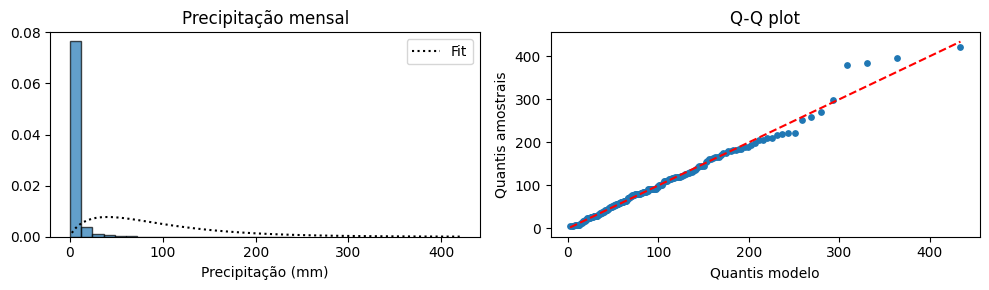

In [20]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

x = np.linspace(2, series_mensal_treated.max(), 100)

ax[0].plot(x, model_mensal.pdf(x), 'k', linestyle=':', label=f'Fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].set_title('Precipitação mensal')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].set_ylim(top=0.08)
ax[0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series_mensal_treated) + 1) - 0.5) / len(series_mensal_treated)
theoretical_q, sample_q = model_mensal.ppf(p), np.sort(series_mensal_treated)
ax[1].scatter(theoretical_q, sample_q, s=15)
min_q = min(theoretical_q.min(), sample_q.min())
max_q = max(theoretical_q.max(), sample_q.max())
ax[1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[1].set_title(f'Q-Q plot')
ax[1].set_xlabel('Quantis modelo')
ax[1].set_ylabel('Quantis amostrais')

fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

### Diagnóstico PIT

In [21]:
pit = model_mensal.cdf(series_mensal_treated)

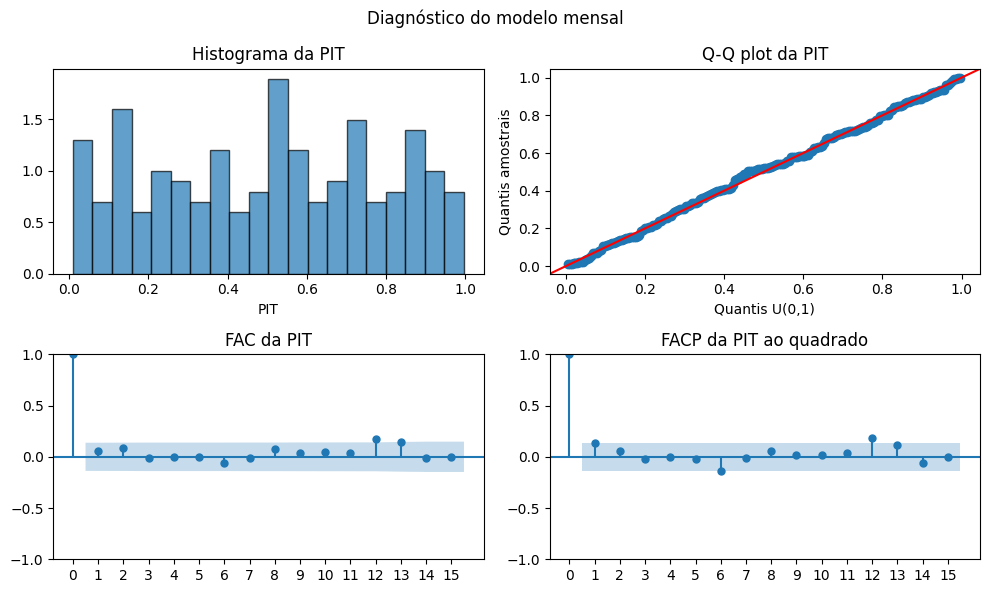

In [22]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo mensal')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

# EGPD (sem zeros)
$$
\begin{aligned}
y_t &\sim G\left\{
H_\xi\left(\dfrac{x}{\sigma}\right)
\right\}, \qquad \sigma>0\\
G(v)
&=
v^\kappa,
\qquad
\kappa>0
\end{aligned}
$$

## ML

### Estimação

In [23]:
# remoção de observações nulas
series_treated = series[series>0]
series_molhado_treated = series_molhado[series_molhado>0]
series_seco_treated = series_seco[series_seco>0]

In [24]:
# estimação all data
model_all = naveau.fit(series_treated)
res_all = model_all.summary(print_results=False)
      
# estimação com estação molhada
model_molhado = naveau.fit(series_molhado_treated)
res_molhado = model_molhado.summary(print_results=False)

# estimação com estação seca
model_seco = naveau.fit(series_seco_treated)
res_seco = model_seco.summary(print_results=False)

# estimação sazonal
model_sazonal = naveau.fit(series_treated, dummy=dummy[series_treated.index])
res_sazonal = model_sazonal.summary(print_results=False)

In [25]:
# salvar resultados
df_params.at[('kappa','ML'),'Diário'] = res_all[0]
df_params.at[('sigma','ML'),'Diário'] = res_all[1]
df_params.at[('xi','ML'),'Diário'] = res_all[2]

df_params.at[('kappa','ML'),'Diário: estação molhada'] = res_molhado[0]
df_params.at[('sigma','ML'),'Diário: estação molhada'] = res_molhado[1]
df_params.at[('xi','ML'),'Diário: estação molhada'] = res_molhado[2]

df_params.at[('kappa','ML'),'Diário: estação seca'] = res_seco[0]
df_params.at[('sigma','ML'),'Diário: estação seca'] = res_seco[1]
df_params.at[('xi','ML'),'Diário: estação seca'] = res_seco[2]

df_params.at[('kappa','ML'),'Diário sazonal'] = res_sazonal[0]
df_params.at[('sigma','ML'),'Diário sazonal'] = res_sazonal[1]
df_params.at[('xi','ML'),'Diário sazonal'] = res_sazonal[2]
df_params.at[('xi1','ML'),'Diário sazonal'] = res_sazonal[3]

df_params.dropna(axis=0, how='all').fillna('-')

,,Mensal,Mensal sazonal,Diário,Diário: estação seca,Diário: estação molhada,Diário sazonal
Parâmetro,Estimação,,,,,,
kappa,ML,"1.799 (1.33, 2.27)","2.411 (1.86, 2.96)","0.915 (0.81, 1.02)","0.923 (0.79, 1.06)","0.890 (0.74, 1.04)","0.896 (0.80, 0.99)"
sigma,ML,"68.221 (48.36, 88.08)","46.585 (34.58, 58.59)","3.783 (2.91, 4.65)","3.995 (2.83, 5.16)","3.830 (2.42, 5.24)","3.984 (3.09, 4.88)"
xi,ML,"-0.011 (-0.15, 0.13)","0.248 (0.08, 0.42)","0.691 (0.57, 0.81)","0.505 (0.34, 0.67)","0.798 (0.60, 0.99)","0.515 (0.38, 0.65)"
xi1,ML,-,"-0.386 (-0.53, -0.24)",-,-,-,"0.257 (0.13, 0.38)"


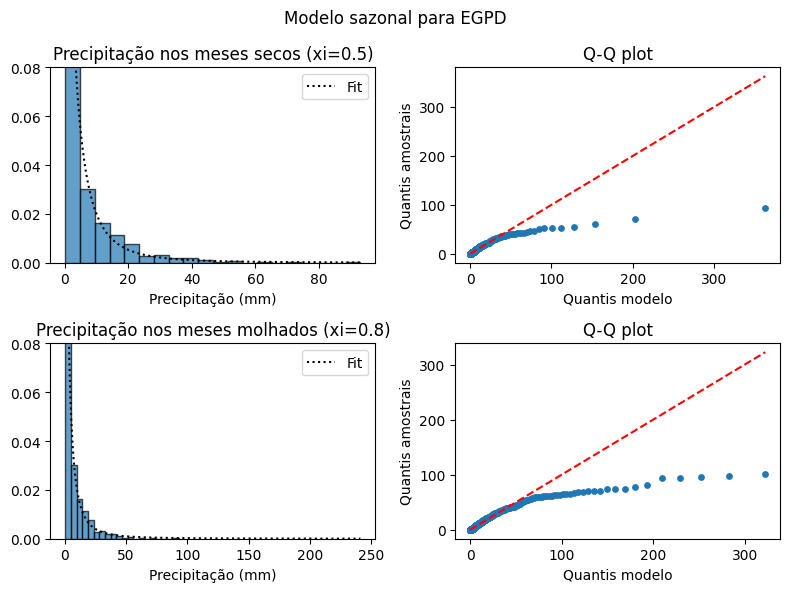

In [26]:
fig, ax = plt.subplots(2,2, figsize=(8, 6))

# meses secos
x = np.linspace(series_seco_treated.min(), series_seco_treated.max(), len(series_seco_treated))

ax[0][0].plot(x, model_sazonal.pdf(x, dummy[series_seco_treated.index]), 'k', linestyle=':', label=f'Fit')
ax[0][0].hist(series_seco_treated, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0][0].set_title(f'Precipitação nos meses secos (xi={model_sazonal.xi:.1f})')
ax[0][0].set_xlabel('Precipitação (mm)')
ax[0][0].set_ylim(top=0.08)
ax[0][0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series_seco_treated) + 1) - 0.5) / len(series_seco_treated)
theoretical_q = model_sazonal.ppf(p, dummy[series_seco_treated.index])
sample_q = np.sort(series_seco_treated)
ax[0][1].scatter(theoretical_q, sample_q, s=15)
min_q = min(theoretical_q.min(), sample_q.min())
max_q = max(theoretical_q.max(), sample_q.max())
ax[0][1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[0][1].set_title(f'Q-Q plot')
ax[0][1].set_xlabel('Quantis modelo')
ax[0][1].set_ylabel('Quantis amostrais')

# meses molhados
x = np.linspace(series_molhado_treated.min(), series_molhado_treated.max(), len(series_molhado_treated))

ax[1][0].plot(x, model_sazonal.pdf(x, dummy[series_molhado_treated.index]), 'k', linestyle=':', label=f'Fit')
ax[1][0].hist(series_seco_treated, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[1][0].set_title(f'Precipitação nos meses molhados (xi={model_sazonal.xi + model_sazonal.xi1:.1f})')
ax[1][0].set_xlabel('Precipitação (mm)')
ax[1][0].set_ylim(top=0.08)
ax[1][0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series_molhado_treated) + 1) - 0.5) / len(series_molhado_treated)
theoretical_q = model_sazonal.ppf(p, dummy[series_molhado_treated.index])[:-5]
sample_q = np.sort(series_molhado_treated)
ax[1][1].scatter(theoretical_q, sample_q[:-5], s=15)
min_q = min(theoretical_q.min(), sample_q[:-5].min())
max_q = max(theoretical_q.max(), sample_q[:-5].max())
ax[1][1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[1][1].set_title(f'Q-Q plot')
ax[1][1].set_xlabel('Quantis modelo')
ax[1][1].set_ylabel('Quantis amostrais')

fig.suptitle('Modelo sazonal para EGPD')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

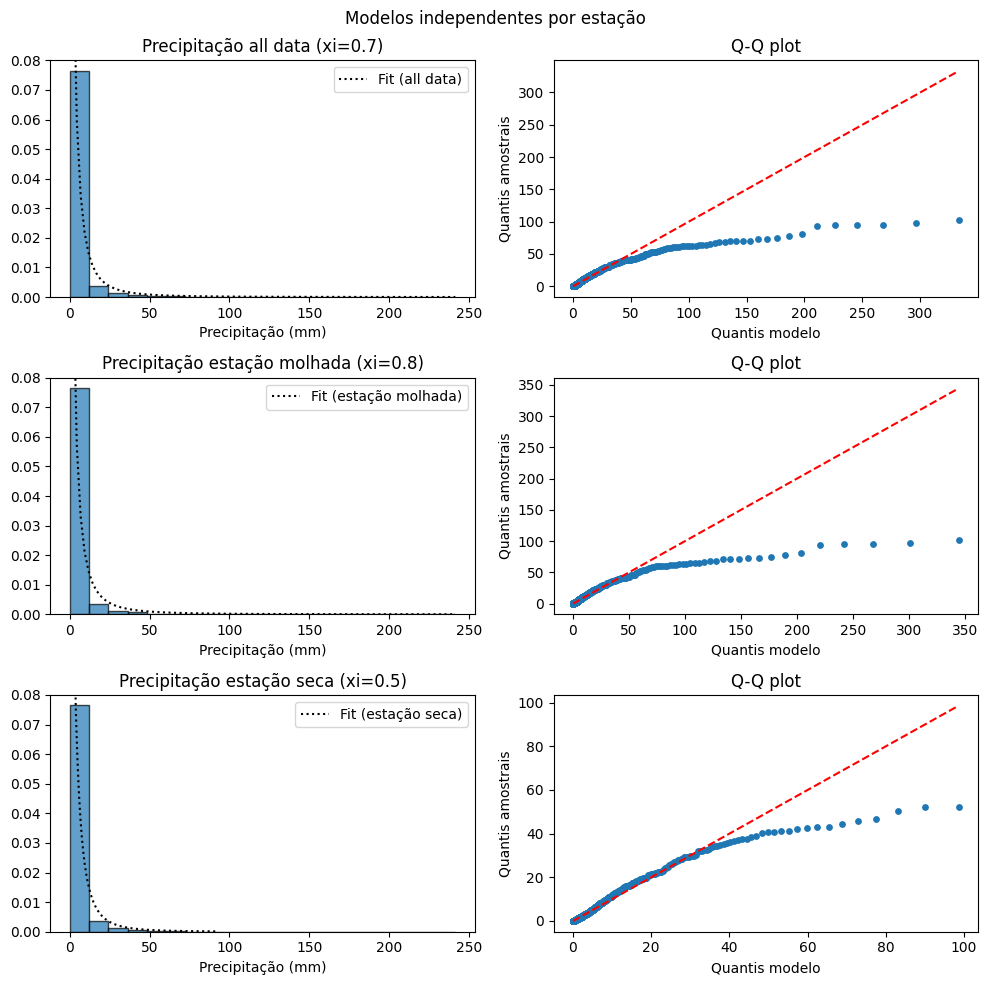

In [27]:
fig, ax = plt.subplots(3,2, figsize=(10, 10))

model_names = ['all data','estação molhada','estação seca']
models = [model_all, model_molhado, model_seco]
data = [series_treated, series_molhado_treated, series_seco_treated]

for i in range(3):
    model_fit = models[i]
    x = np.linspace(2, data[i].max(), 100)

    ax[i][0].plot(x, models[i].pdf(x), 'k', linestyle=':', label=f'Fit ({model_names[i]})')
    ax[i][0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
    ax[i][0].set_title('Precipitação ' + model_names[i] + f' (xi={models[i].xi:.1f})')
    ax[i][0].set_xlabel('Precipitação (mm)')
    ax[i][0].set_ylim(top=0.08)
    ax[i][0].legend()
    
    # probabilidades teóricas
    p = (np.arange(1, len(data[i]) + 1) - 0.5) / len(data[i])
    theoretical_q, sample_q = models[i].ppf(p), np.sort(data[i])
    ax[i][1].scatter(theoretical_q[:-5], sample_q[:-5], s=15)
    min_q = min(theoretical_q[:-5].min(), sample_q[:-5].min())
    max_q = max(theoretical_q[:-5].max(), sample_q[:-5].max())
    ax[i][1].plot([min_q, max_q], [min_q, max_q], 'r--')
    ax[i][1].set_title(f'Q-Q plot')
    ax[i][1].set_xlabel('Quantis modelo')
    ax[i][1].set_ylabel('Quantis amostrais')
    i+=1


fig.suptitle('Modelos independentes por estação')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

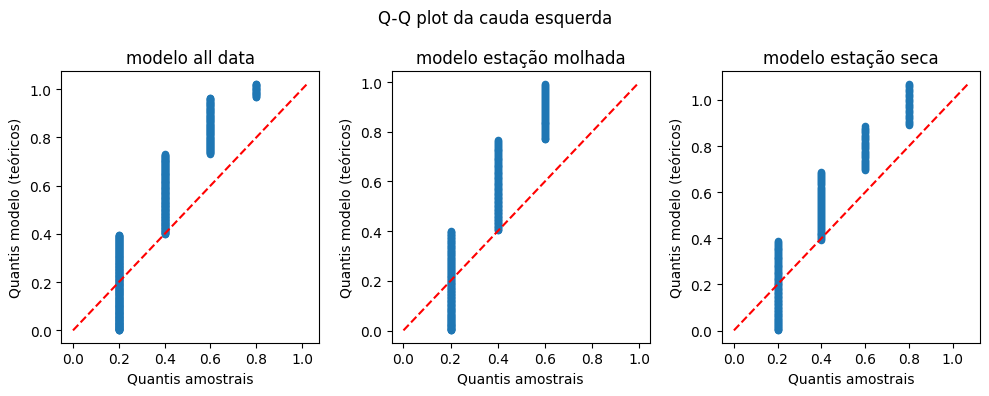

In [28]:
fig, ax = plt.subplots(1,3, figsize=(10, 4))

model_names = ['all data','estação molhada','estação seca']
models = [model_all, model_molhado, model_seco]
data = [series_treated, series_molhado_treated, series_seco_treated]

for i in range(3):
    model_fit = models[i]
    
    # probabilidades teóricas
    p = (np.arange(1, len(data[i]) + 1) - 0.5) / len(data[i])
    theoretical_q, sample_q = models[i].ppf(p), np.sort(data[i])
    tail_idx = p <= 0.25 # apenas os quantis pequenos (ex: 0-5%)
    
    ax[i].scatter(sample_q[tail_idx], theoretical_q[tail_idx], s=20)
    
    min_q = min(sample_q[tail_idx].min(), theoretical_q[tail_idx].min())
    max_q = max(sample_q[tail_idx].max(), theoretical_q[tail_idx].max())
    ax[i].plot([min_q, max_q], [min_q, max_q], 'r--')
    ax[i].set_title(f'modelo {model_names[i]}')
    ax[i].set_ylabel('Quantis modelo (teóricos)')
    ax[i].set_xlabel('Quantis amostrais')

fig.suptitle('Q-Q plot da cauda esquerda')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

### Diagnóstico PIT

In [29]:
pit = model_sazonal.cdf(series_treated, dummy[series_treated.index])

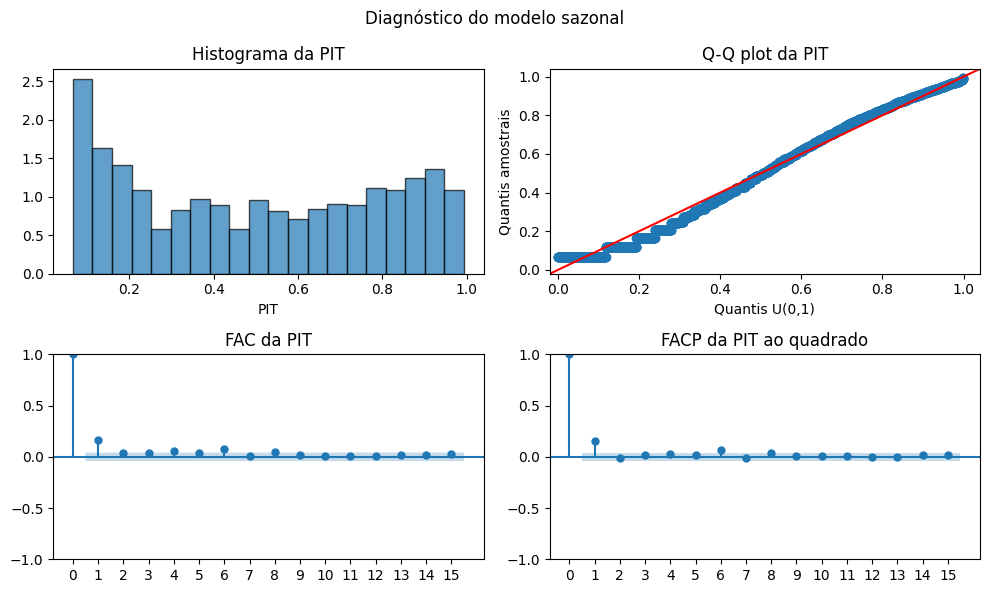

In [30]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo sazonal')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [31]:
pit = model_seco.cdf(series_seco_treated)

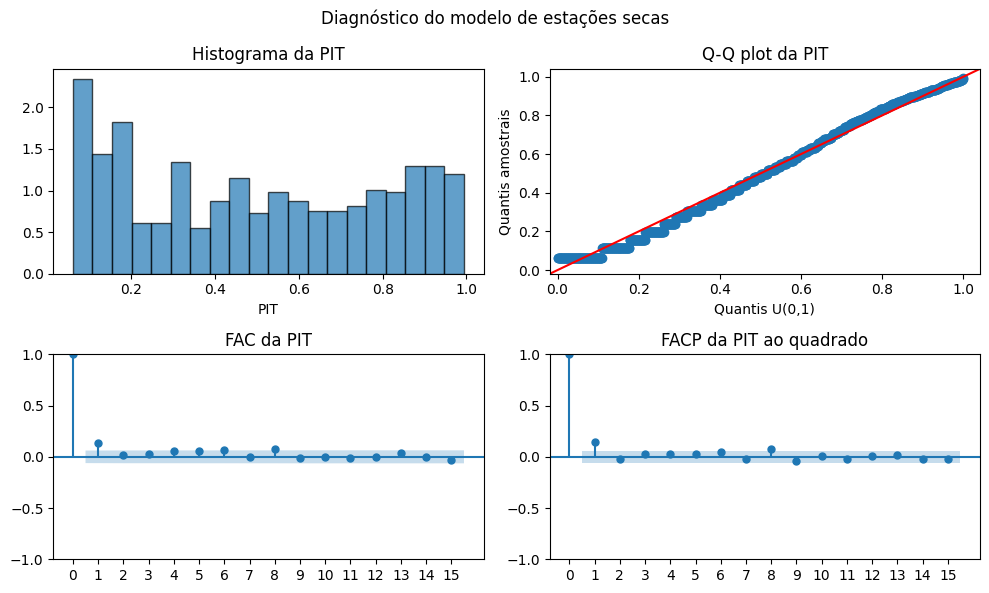

In [32]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo de estações secas')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

## ML censurada

### Estimação

In [33]:
# estimação all data
C=0.5
model_all = naveau.fit(series_treated, censored=True, C=C)
res_all = model_all.summary(print_results=False)
      
# estimação com estação molhada
model_molhado = naveau.fit(series_molhado_treated, censored=True, C=C)
res_molhado = model_molhado.summary(print_results=False)

# estimação com estação seca
model_seco = naveau.fit(series_seco_treated, censored=True, C=C)
res_seco = model_seco.summary(print_results=False)

# estimação sazonal
model_sazonal = naveau.fit(series_treated, dummy=dummy[series_treated.index], censored=True, C=C)
res_sazonal = model_sazonal.summary(print_results=False)

In [34]:
# salvar resultados
df_params.at[('kappa','ML-c'),'Diário'] = res_all[0]
df_params.at[('sigma','ML-c'),'Diário'] = res_all[1]
df_params.at[('xi','ML-c'),'Diário'] = res_all[2]

df_params.at[('kappa','ML-c'),'Diário: estação molhada'] = res_molhado[0]
df_params.at[('sigma','ML-c'),'Diário: estação molhada'] = res_molhado[1]
df_params.at[('xi','ML-c'),'Diário: estação molhada'] = res_molhado[2]

df_params.at[('kappa','ML-c'),'Diário: estação seca'] = res_seco[0]
df_params.at[('sigma','ML-c'),'Diário: estação seca'] = res_seco[1]
df_params.at[('xi','ML-c'),'Diário: estação seca'] = res_seco[2]

df_params.at[('kappa','ML-c'),'Diário sazonal'] = res_sazonal[0]
df_params.at[('sigma','ML-c'),'Diário sazonal'] = res_sazonal[1]
df_params.at[('xi','ML-c'),'Diário sazonal'] = res_sazonal[2]
df_params.at[('xi1','ML-c'),'Diário sazonal'] = res_sazonal[3]

df_params.fillna('-')

Mensal         Mensal sazonal  \
Parâmetro Estimação                                                 
kappa     ML            1.799 (1.33, 2.27)     2.411 (1.86, 2.96)   
          ML-c                           -                      -   
sigma     ML         68.221 (48.36, 88.08)  46.585 (34.58, 58.59)   
          ML-c                           -                      -   
xi        ML          -0.011 (-0.15, 0.13)     0.248 (0.08, 0.42)   
          ML-c                           -                      -   
xi1       ML                             -  -0.386 (-0.53, -0.24)   
          ML-c                           -                      -   

                                  Diário Diário: estação seca  \
Parâmetro Estimação                                             
kappa     ML          0.915 (0.81, 1.02)   0.923 (0.79, 1.06)   
          ML-c        0.545 (0.50, 0.59)   0.603 (0.53, 0.68)   
sigma     ML          3.783 (2.91, 4.65)   3.995 (2.83, 5.16)   
          ML-c       9.146 (7.79, 10.51)   7.900 (6.17, 9.63)   
xi        ML          0.691 (0.57, 0.81)   0.505 (0.34, 0.67)   
          ML-c        0.305 (0.22, 0.40)   0.193 (0.06, 0.32)   
xi1       ML                           -                    -   
          ML-c                         -                    -   

                    Diário: estação molhada       Diário sazonal  
Parâmetro Estimação                                               
kappa     ML             0.890 (0.74, 1.04)   0.896 (0.80, 0.99)  
          ML-c           0.488 (0.44, 0.54)   0.538 (0.50, 0.58)  
sigma     ML             3.830 (2.42, 5.24)   3.984 (3.09, 4.88)  
          ML-c         11.310 (9.03, 13.59)  9.482 (8.08, 10.88)  
xi        ML             0.798 (0.60, 0.99)   0.515 (0.38, 0.65)  
          ML-c           0.312 (0.19, 0.44)   0.107 (0.01, 0.21)  
xi1       ML                              -   0.257 (0.13, 0.38)  
          ML-c                            -   0.287 (0.18, 0.40)

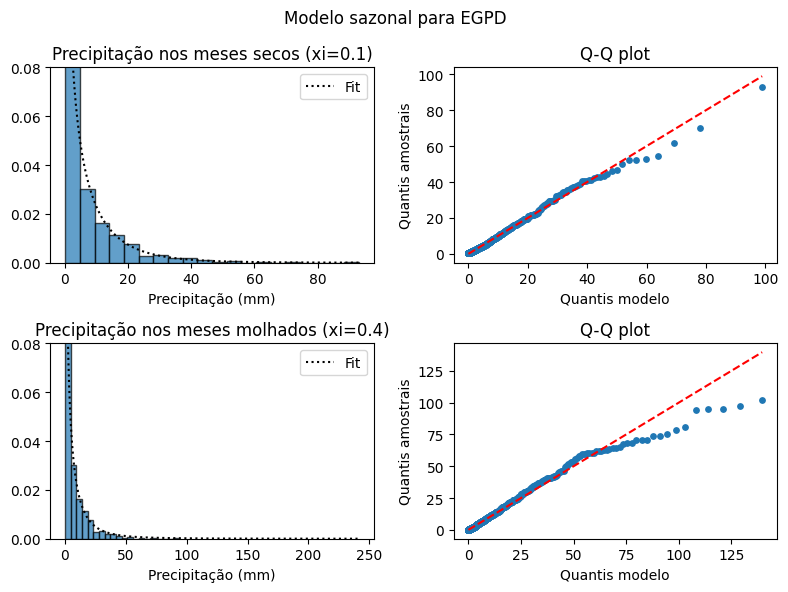

In [35]:
fig, ax = plt.subplots(2,2, figsize=(8, 6))

# meses secos
x = np.linspace(series_seco_treated.min(), series_seco_treated.max(), len(series_seco_treated))

ax[0][0].plot(x, model_sazonal.pdf(x, dummy[series_seco_treated.index]), 'k', linestyle=':', label=f'Fit')
ax[0][0].hist(series_seco_treated, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0][0].set_title(f'Precipitação nos meses secos (xi={model_sazonal.xi:.1f})')
ax[0][0].set_xlabel('Precipitação (mm)')
ax[0][0].set_ylim(top=0.08)
ax[0][0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series_seco_treated) + 1) - 0.5) / len(series_seco_treated)
theoretical_q = model_sazonal.ppf(p, dummy[series_seco_treated.index])
sample_q = np.sort(series_seco_treated)
ax[0][1].scatter(theoretical_q, sample_q, s=15)
min_q = min(theoretical_q.min(), sample_q.min())
max_q = max(theoretical_q.max(), sample_q.max())
ax[0][1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[0][1].set_title(f'Q-Q plot')
ax[0][1].set_xlabel('Quantis modelo')
ax[0][1].set_ylabel('Quantis amostrais')

# meses molhados
x = np.linspace(series_molhado_treated.min(), series_molhado_treated.max(), len(series_molhado_treated))

ax[1][0].plot(x, model_sazonal.pdf(x, dummy[series_molhado_treated.index]), 'k', linestyle=':', label=f'Fit')
ax[1][0].hist(series_seco_treated, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[1][0].set_title(f'Precipitação nos meses molhados (xi={model_sazonal.xi + model_sazonal.xi1:.1f})')
ax[1][0].set_xlabel('Precipitação (mm)')
ax[1][0].set_ylim(top=0.08)
ax[1][0].legend()

# probabilidades teóricas
p = (np.arange(1, len(series_molhado_treated) + 1) - 0.5) / len(series_molhado_treated)
theoretical_q = model_sazonal.ppf(p, dummy[series_molhado_treated.index])[:-5]
sample_q = np.sort(series_molhado_treated)
ax[1][1].scatter(theoretical_q, sample_q[:-5], s=15)
min_q = min(theoretical_q.min(), sample_q[:-5].min())
max_q = max(theoretical_q.max(), sample_q[:-5].max())
ax[1][1].plot([min_q, max_q], [min_q, max_q], 'r--')
ax[1][1].set_title(f'Q-Q plot')
ax[1][1].set_xlabel('Quantis modelo')
ax[1][1].set_ylabel('Quantis amostrais')

fig.suptitle('Modelo sazonal para EGPD')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

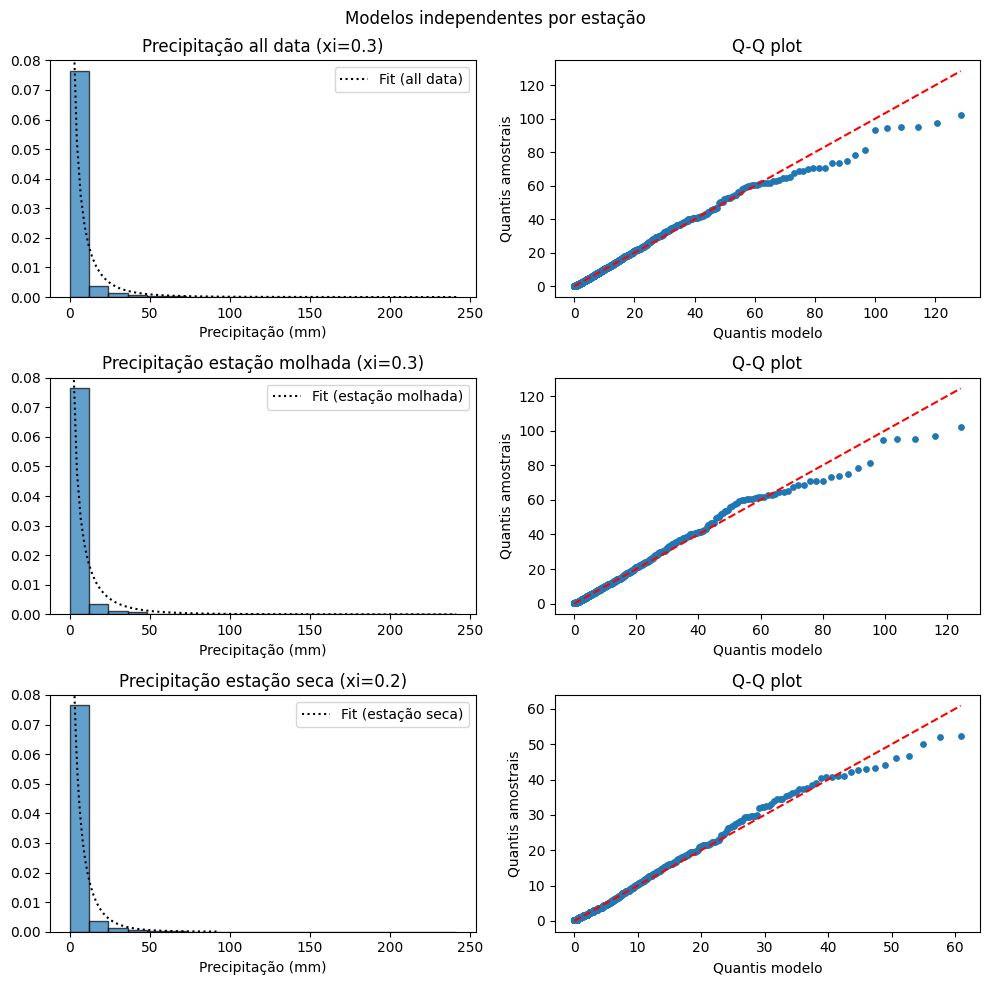

In [36]:
fig, ax = plt.subplots(3,2, figsize=(10, 10))

model_names = ['all data','estação molhada','estação seca']
models = [model_all, model_molhado, model_seco]
data = [series_treated, series_molhado_treated, series_seco_treated]

for i in range(3):
    model_fit = models[i]
    x = np.linspace(2, data[i].max(), 100)

    ax[i][0].plot(x, models[i].pdf(x), 'k', linestyle=':', label=f'Fit ({model_names[i]})')
    ax[i][0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
    ax[i][0].set_title('Precipitação ' + model_names[i] + f' (xi={models[i].xi:.1f})')
    ax[i][0].set_xlabel('Precipitação (mm)')
    ax[i][0].set_ylim(top=0.08)
    ax[i][0].legend()
    
    # probabilidades teóricas
    p = (np.arange(1, len(data[i]) + 1) - 0.5) / len(data[i])
    theoretical_q, sample_q = models[i].ppf(p), np.sort(data[i])
    ax[i][1].scatter(theoretical_q[:-5], sample_q[:-5], s=15)
    min_q = min(theoretical_q[:-5].min(), sample_q[:-5].min())
    max_q = max(theoretical_q[:-5].max(), sample_q[:-5].max())
    ax[i][1].plot([min_q, max_q], [min_q, max_q], 'r--')
    ax[i][1].set_title(f'Q-Q plot')
    ax[i][1].set_xlabel('Quantis modelo')
    ax[i][1].set_ylabel('Quantis amostrais')
    i+=1

fig.suptitle('Modelos independentes por estação')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [37]:
# calcula níveis de retorno
Ts = [50,100,200,500]
cols = [f'{T} ({1-1/T:.3f})' for T in Ts]
df_quantis = pd.DataFrame(index=['Mensal', #'Sazonal (M): estação seca', 'Sazonal (M): estação molhada',
                                 'Diário','Diário: estação seca', 'Diário: estação molhada'], columns = cols)

df_quantis.loc['Mensal'] = [model_mensal.ppf(1-1/T) for T in Ts]
# df_quantis.loc['Sazonal (M): estação seca'] = [model_mensal_s.ppf(1-1/T, dummy=1) for T in Ts]
# df_quantis.loc['Sazonal (M): estação molhada'] = [model_mensal_s.ppf(1-1/T, dummy=0) for T in Ts]
df_quantis.loc['Diário'] = [model_all.ppf(1-1/T) for T in Ts]
df_quantis.loc['Diário: estação seca'] = [model_seco.ppf(1-1/T) for T in Ts]
df_quantis.loc['Diário: estação molhada'] = [model_molhado.ppf(1-1/T) for T in Ts]
df_quantis.loc['Sazonal: estação seca'] = [model_sazonal.ppf(1-1/T, dummy=0) for T in Ts]
df_quantis.loc['Sazonal: estação molhada'] = [model_sazonal.ppf(1-1/T, dummy=1) for T in Ts]

df_quantis = df_quantis.astype(float)
# print('Quantis extremos e níveis de retorno:')
# df_quantis.round(2)

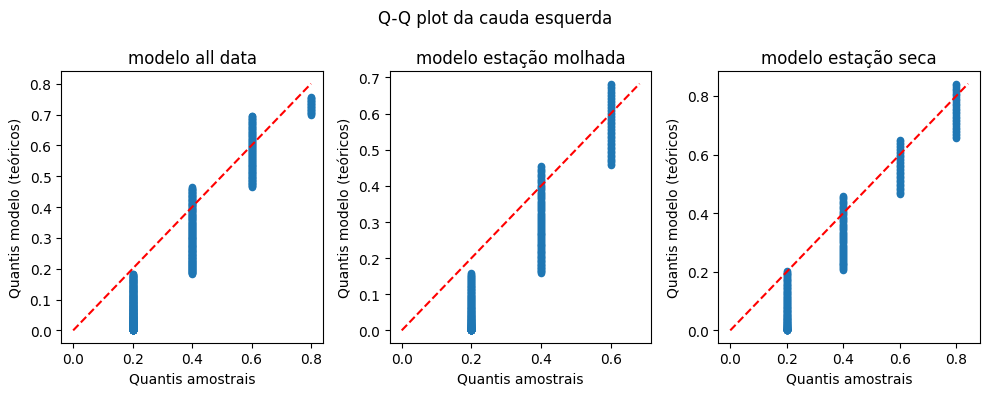

In [38]:
fig, ax = plt.subplots(1,3, figsize=(10, 4))

model_names = ['all data','estação molhada','estação seca']
models = [model_all, model_molhado, model_seco]
data = [series_treated, series_molhado_treated, series_seco_treated]

for i in range(3):
    model_fit = models[i]
    
    # probabilidades teóricas
    p = (np.arange(1, len(data[i]) + 1) - 0.5) / len(data[i])
    theoretical_q, sample_q = models[i].ppf(p), np.sort(data[i])
    tail_idx = p <= 0.25 # apenas os quantis pequenos (ex: 0-5%)
    
    ax[i].scatter(sample_q[tail_idx], theoretical_q[tail_idx], s=20)
    
    min_q = min(sample_q[tail_idx].min(), theoretical_q[tail_idx].min())
    max_q = max(sample_q[tail_idx].max(), theoretical_q[tail_idx].max())
    ax[i].plot([min_q, max_q], [min_q, max_q], 'r--')
    ax[i].set_title(f'modelo {model_names[i]}')
    ax[i].set_ylabel('Quantis modelo (teóricos)')
    ax[i].set_xlabel('Quantis amostrais')

fig.suptitle('Q-Q plot da cauda esquerda')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

### Diagnóstico PIT

In [39]:
pit = np.zeros(len(series_treated))

# dados censurados
idx = series_treated < C
pit[idx] = rng.uniform(0, model_sazonal.cdf(C), size=idx.sum())

# positivos
pit[~idx] = model_sazonal.cdf(series_treated[~idx], dummy[series_treated.index][~idx])

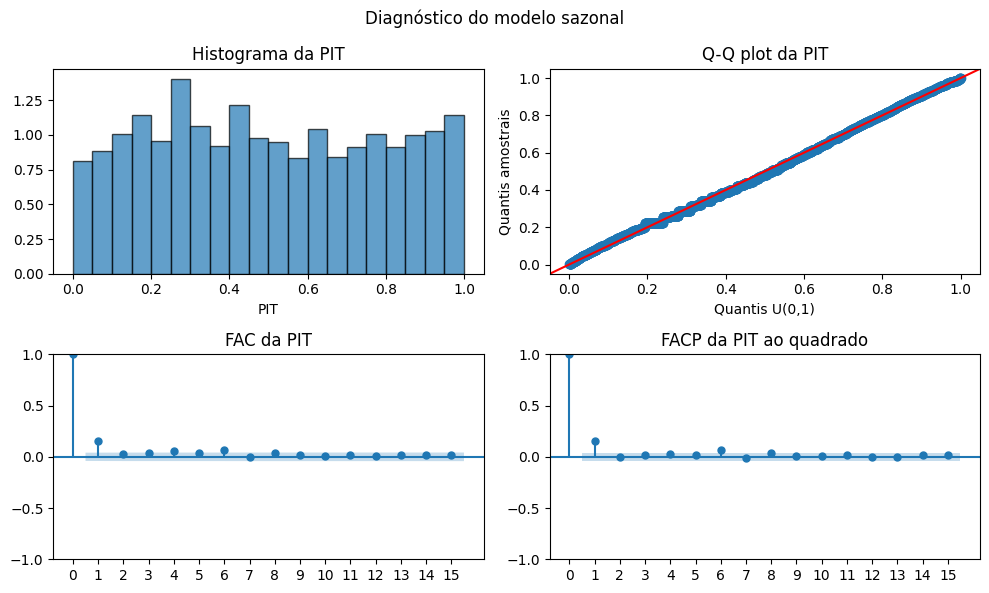

In [40]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo sazonal')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [41]:
pit = np.zeros(len(series_seco_treated))
# dados censurados
idx = series_seco_treated < C
pit[idx] = rng.uniform(0, model_seco.cdf(C), size=idx.sum())
# positivos
pit[~idx] = model_seco.cdf(series_seco_treated[~idx])

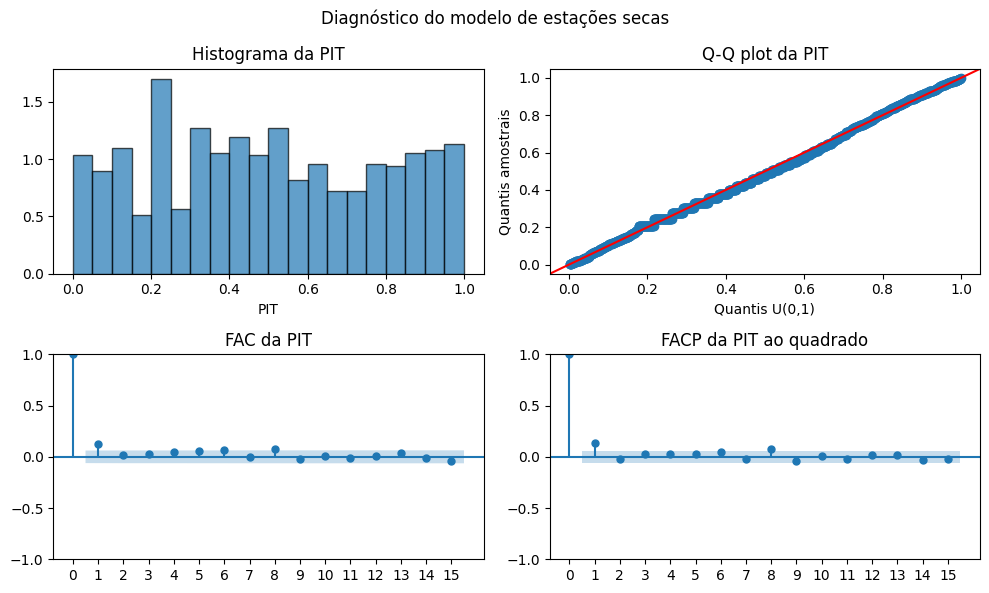

In [42]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo de estações secas')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

# ZIEGPD

## Estimação

In [43]:
C = 0.5 # censura

# estimação all data
pi_hat_all = np.mean(series>0)
model_all = naveau.fit(series[series>0], censored=True, C=C)
res_all = model_all.summary(print_results=False)
      
# estimação com estação molhada
pi_hat_molhado = np.mean(series_molhado>0)
model_molhado = naveau.fit(series_molhado[series_molhado>0], censored=True, C=C)
res_molhado = model_molhado.summary(print_results=False)

# estimação com estação seca
pi_hat_seco = np.mean(series_seco>0)
model_seco = naveau.fit(series_seco[series_seco>0], censored=True, C=C)
res_seco = model_seco.summary(print_results=False)

# estimação sazonal
pi_hat_s = np.mean(series>0)
model_s = naveau.fit(series[series>0], censored=True, C=C, dummy=dummy[series[series>0].index])
res_s = model_s.summary(print_results=False)

In [44]:
# salva resultados
index = pd.MultiIndex.from_product([['pi','kappa','sigma','xi','xi1'], ['ML-c']], names=['Parâmetro', 'Estimação'])
df_params_z = pd.DataFrame(index=index, columns=['ZIEGPD','ZIEGPD: estação seca', 'ZIEGPD: estação molhada','ZIEGPD sazonal'])

df_params_z.at[('pi','ML-c'),'ZIEGPD'] = pi_hat_all.round(3)
df_params_z.at[('kappa','ML-c'),'ZIEGPD'] = res_all[0]
df_params_z.at[('sigma','ML-c'),'ZIEGPD'] = res_all[1]
df_params_z.at[('xi','ML-c'),'ZIEGPD'] = res_all[2]

df_params_z.at[('pi','ML-c'),'ZIEGPD: estação molhada'] = pi_hat_molhado.round(3)
df_params_z.at[('kappa','ML-c'),'ZIEGPD: estação molhada'] = res_molhado[0]
df_params_z.at[('sigma','ML-c'),'ZIEGPD: estação molhada'] = res_molhado[1]
df_params_z.at[('xi','ML-c'),'ZIEGPD: estação molhada'] = res_molhado[2]

df_params_z.at[('pi','ML-c'),'ZIEGPD: estação seca'] = pi_hat_seco.round(3)
df_params_z.at[('kappa','ML-c'),'ZIEGPD: estação seca'] = res_seco[0]
df_params_z.at[('sigma','ML-c'),'ZIEGPD: estação seca'] = res_seco[1]
df_params_z.at[('xi','ML-c'),'ZIEGPD: estação seca'] = res_seco[2]

df_params_z.at[('pi','ML-c'),'ZIEGPD sazonal'] = pi_hat_s.round(3)
df_params_z.at[('kappa','ML-c'),'ZIEGPD sazonal'] = res_s[0]
df_params_z.at[('sigma','ML-c'),'ZIEGPD sazonal'] = res_s[1]
df_params_z.at[('xi','ML-c'),'ZIEGPD sazonal'] = res_s[2]
df_params_z.at[('xi1','ML-c'),'ZIEGPD sazonal'] = res_s[3]
# df_params_z.fillna('-')

In [45]:
def p_star(p, pi_hat):
    # o quantil é igual a zero até o p=1-pi (proporção de zeros),
    # depois segue a cauda do EGPD
    pstar = (p - (1-pi_hat))/pi_hat
    return np.maximum(pstar, 0)

In [46]:
# calcula níveis de retorno
Ts = [50,100,200,500]
cols = [f'{T} ({1-1/T:.3f})' for T in Ts]
df_quantis_z = pd.DataFrame(index=['ZIEGPD','ZIEGPD: estação seca', 'ZIEGPD: estação molhada'], columns = cols)

df_quantis_z.loc['ZIEGPD'] = [model_all.ppf(p_star(1-1/T, pi_hat_all)) for T in Ts]
df_quantis_z.loc['ZIEGPD: estação seca'] = [model_seco.ppf(p_star(1-1/T, pi_hat_seco)) for T in Ts]
df_quantis_z.loc['ZIEGPD: estação molhada'] = [model_molhado.ppf(p_star(1-1/T, pi_hat_molhado)) for T in Ts]
df_quantis_z.loc['Sazonal: estação seca'] = [model_s.ppf(p_star(1-1/T, pi_hat_s), dummy=0) for T in Ts]
df_quantis_z.loc['Sazonal: estação molhada'] = [model_s.ppf(p_star(1-1/T, pi_hat_s), dummy=1) for T in Ts]

df_quantis_z = df_quantis_z.astype(float)
# df_quantis_z.round(2)

## Diagnóstico

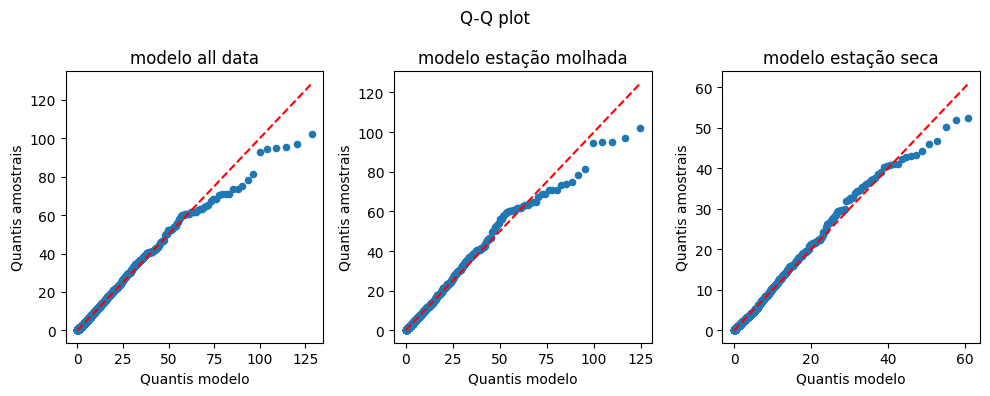

In [47]:
fig, ax = plt.subplots(1,3, figsize=(10, 4))

model_names = ['all data','estação molhada','estação seca']
models = [model_all, model_molhado, model_seco]
data = [series, series_molhado, series_seco]
pi_hat = [pi_hat_all, pi_hat_molhado, pi_hat_seco]

for i in range(3):
    model_fit = models[i]
    
    # probabilidades teóricas
    p = (np.arange(1, len(data[i]) + 1) - 0.5) / len(data[i])
    pstar = p_star(p,pi_hat[i])
    theoretical_q, sample_q = models[i].ppf(pstar)[:-5], np.sort(data[i])[:-5]
    ax[i].scatter(theoretical_q, sample_q, s=20)
    min_q = min(theoretical_q.min(), sample_q.min())
    max_q = max(theoretical_q.max(), sample_q.max())
    ax[i].plot([min_q, max_q], [min_q, max_q], 'r--')
    ax[i].set_title(f'modelo {model_names[i]}')
    ax[i].set_xlabel('Quantis modelo')
    ax[i].set_ylabel('Quantis amostrais')

fig.suptitle('Q-Q plot')
fig.tight_layout()
# plot_count+=1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [48]:
# cálculo da pit pra modelo misto (ziegpd)
pit = np.zeros(len(series))

# zeros
idx = (series == 0)
lower, upper = 0, 1-pi_hat_s
pit[idx] = rng.uniform(lower, upper, size=idx.sum())

# dados censurados
idx = (series > 0) & (series < C)
lower, upper = 1-pi_hat_s, (1-pi_hat_s) + pi_hat_s * model_s.cdf(C)
pit[idx] = rng.uniform(lower, upper, size=idx.sum())

# positivos
idx = (series >= C)
pit[idx] = (1 - pi_hat_s) + pi_hat_s * model_s.cdf(series[idx], dummy[idx])

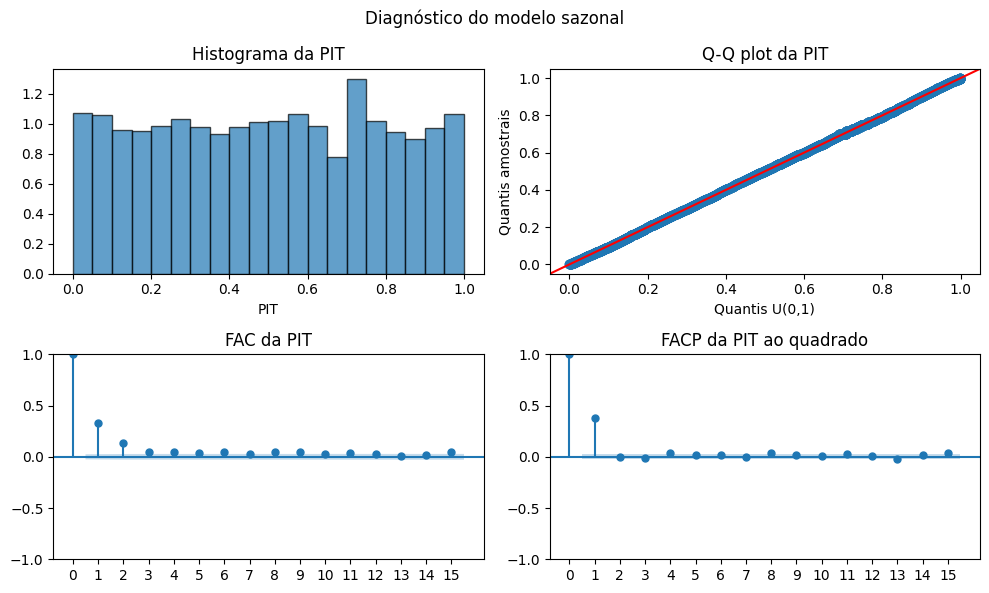

In [49]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo sazonal')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [50]:
# cálculo da pit pra modelo misto (ziegpd)
pit = np.zeros(len(series_seco))

# zeros
idx = (series_seco == 0)
lower, upper = 0, 1-pi_hat_seco
pit[idx] = rng.uniform(lower, upper, size=idx.sum())

# dados censurados
idx = (series_seco > 0) & (series_seco < C)
lower, upper = 1-pi_hat_seco, (1-pi_hat_seco) + pi_hat_seco * model_seco.cdf(C)
pit[idx] = rng.uniform(lower, upper, size=idx.sum())

# positivos
idx = (series_seco >= C)
pit[idx] = (1 - pi_hat_seco) + pi_hat_seco * model_seco.cdf(series_seco[idx])

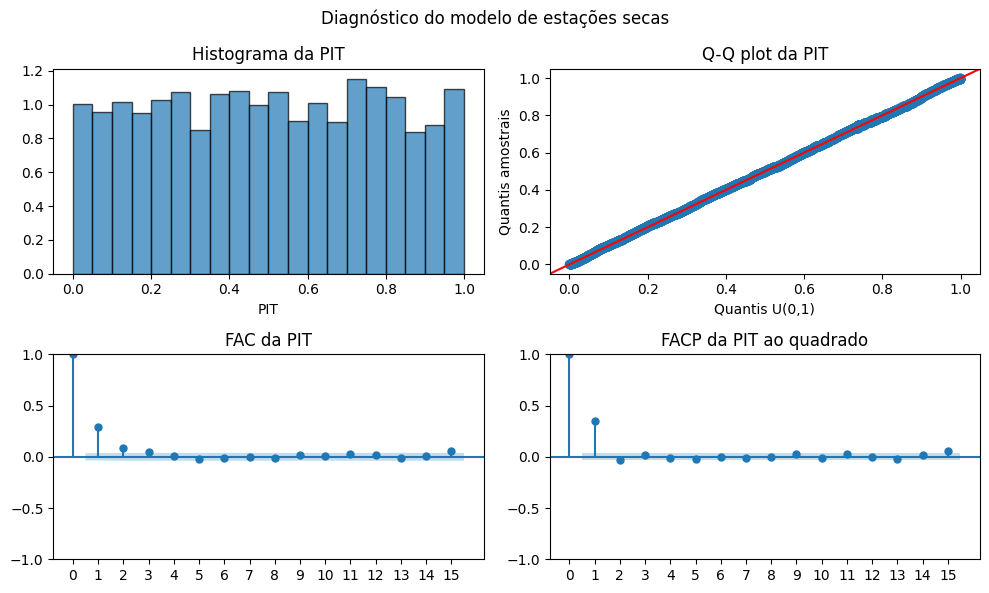

In [51]:
# pit
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# linha 1
ax[0,0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0,0].set_title('Histograma da PIT')
ax[0,0].set_xlabel('PIT')

ax[0,1].set_title('Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[0,1], loc=0, scale=1)
ax[0,1].set_xlabel('Quantis U(0,1)')
ax[0,1].set_ylabel('Quantis amostrais')

# linha 2
lags = 15

plot_acf(pit, lags=lags, ax=ax[1,0], title='FAC da PIT')
ax[1,0].set_xticks(np.arange(lags+1))
ax[1,0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**2, lags=lags, ax=ax[1,1], title='FACP da PIT ao quadrado')
ax[1,1].set_xticks(np.arange(lags+1))
ax[1,1].set_xticklabels(np.arange(lags+1))

fig.suptitle('Diagnóstico do modelo de estações secas')
fig.tight_layout()
# plot_count += 1
# plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

# Resultados

## Parâmetros estimados

In [52]:
print('Parâmetros estimados pelo ZIEGPD (misto):\n')
df_params_z.fillna('-')

Parâmetros estimados pelo ZIEGPD (misto):



,,ZIEGPD,ZIEGPD: estação seca,ZIEGPD: estação molhada,ZIEGPD sazonal
Parâmetro,Estimação,,,,
pi,ML-c,0.384,0.335,0.433,0.384
kappa,ML-c,"0.545 (0.50, 0.59)","0.603 (0.53, 0.68)","0.488 (0.44, 0.54)","0.538 (0.50, 0.58)"
sigma,ML-c,"9.146 (7.79, 10.51)","7.900 (6.17, 9.63)","11.310 (9.03, 13.59)","9.482 (8.08, 10.88)"
xi,ML-c,"0.305 (0.22, 0.40)","0.193 (0.06, 0.32)","0.312 (0.19, 0.44)","0.107 (0.01, 0.21)"
xi1,ML-c,-,-,-,"0.287 (0.18, 0.40)"


In [58]:
print('Parâmetros estimados pelo EGPD (sem zeros):\n')
df_params.iloc[:,:2].dropna(axis=0, how='all').fillna('-')

Parâmetros estimados pelo EGPD (sem zeros):



,,Mensal,Mensal sazonal
Parâmetro,Estimação,,
kappa,ML,"1.799 (1.33, 2.27)","2.411 (1.86, 2.96)"
sigma,ML,"68.221 (48.36, 88.08)","46.585 (34.58, 58.59)"
xi,ML,"-0.011 (-0.15, 0.13)","0.248 (0.08, 0.42)"
xi1,ML,-,"-0.386 (-0.53, -0.24)"


In [59]:
df_params.iloc[:,2:].dropna(axis=0, how='all').fillna('-')

Diário Diário: estação seca  \
Parâmetro Estimação                                             
kappa     ML          0.915 (0.81, 1.02)   0.923 (0.79, 1.06)   
          ML-c        0.545 (0.50, 0.59)   0.603 (0.53, 0.68)   
sigma     ML          3.783 (2.91, 4.65)   3.995 (2.83, 5.16)   
          ML-c       9.146 (7.79, 10.51)   7.900 (6.17, 9.63)   
xi        ML          0.691 (0.57, 0.81)   0.505 (0.34, 0.67)   
          ML-c        0.305 (0.22, 0.40)   0.193 (0.06, 0.32)   
xi1       ML                           -                    -   
          ML-c                         -                    -   

                    Diário: estação molhada       Diário sazonal  
Parâmetro Estimação                                               
kappa     ML             0.890 (0.74, 1.04)   0.896 (0.80, 0.99)  
          ML-c           0.488 (0.44, 0.54)   0.538 (0.50, 0.58)  
sigma     ML             3.830 (2.42, 5.24)   3.984 (3.09, 4.88)  
          ML-c         11.310 (9.03, 13.59)  9.482 (8.08, 10.88)  
xi        ML             0.798 (0.60, 0.99)   0.515 (0.38, 0.65)  
          ML-c           0.312 (0.19, 0.44)   0.107 (0.01, 0.21)  
xi1       ML                              -   0.257 (0.13, 0.38)  
          ML-c                            -   0.287 (0.18, 0.40)

## Níveis de retorno

In [54]:
print('Quantis extremos e níveis de retorno do ZIEGPD (misto):\n')
df_quantis_z.round(2)

Quantis extremos e níveis de retorno do ZIEGPD (misto):



,50 (0.980),100 (0.990),200 (0.995),500 (0.998)
ZIEGPD,31.84,46.15,63.93,94.11
ZIEGPD: estação seca,23.28,32.33,42.73,58.84
ZIEGPD: estação molhada,39.98,58.03,80.57,119.07
Sazonal: estação seca,25.44,34.07,43.44,57.00
Sazonal: estação molhada,36.86,55.62,80.39,125.57


In [55]:
print('Quantis extremos e níveis de retorno do EGPD (sem zeros):\n')
df_quantis.round(2)

Quantis extremos e níveis de retorno do EGPD (sem zeros):



,50 (0.980),100 (0.990),200 (0.995),500 (0.998)
Mensal,299.15,344.13,388.69,447.02
Diário,52.45,71.74,95.63,136.11
Diário: estação seca,38.15,49.40,62.29,82.22
Diário: estação molhada,62.29,85.89,115.26,165.32
Sazonal: estação seca,37.54,47.19,57.62,72.66
Sazonal: estação molhada,64.23,91.73,127.93,193.85
